In [1]:
%pwd

'd:\\Tipto\\OmniChef-Nexus\\notebooks'

In [2]:
import os
os.chdir("../")

In [3]:
%pwd

'd:\\Tipto\\OmniChef-Nexus'

### creating an multi-modal dataset
---
* Dataset format: a full recipe card image and a full recipe markdown for each sample.

### Resources:
  * Dataset: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions/data

### Data Filerting
* We want  ~15k samples
    - step-1: sort based on rating.
    - step-2: filter out recipes which has n_steps <= 20 and n_ingredients <= 20
    - step-3: take a sample of 15k from the filtered version

In [4]:
import pandas as pd
recipes_df = pd.read_csv("data/all csv files/RAW_recipes.csv")
recipes_df.head(2)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6


In [ ]:
interactions_df = pd.read_csv("data/all csv files/RAW_interactions.csv")

In [ ]:
interactions_df.head(2)

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."


In [ ]:
(interactions_df['review'][0])

'Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and a pinch of salt.  Used low fat sour cream.  Thanks.'

In [ ]:
recipes_df.shape , interactions_df.shape

((231637, 12), (1132367, 5))

In [ ]:
recipes_df.isna().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [ ]:
interactions_df.isna().sum()

user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

In [ ]:
# For now we want around 10k samples
# we can take ingredients with till 25 max and steps 25 max

In [ ]:
recipes_df['n_ingredients'].value_counts()

n_ingredients
8     25532
7     24599
9     24599
10    22430
6     21840
11    19094
5     18217
12    15165
4     12650
13    11640
14     8284
3      6800
15     6014
16     4145
17     2793
2      2127
18     1913
19     1279
20      852
21      529
22      346
23      244
24      178
25      107
26       68
27       55
28       33
1        25
29       22
30       20
31       13
32        5
33        4
35        4
34        3
37        2
40        2
43        1
38        1
36        1
39        1
Name: count, dtype: int64

<Axes: xlabel='n_steps'>

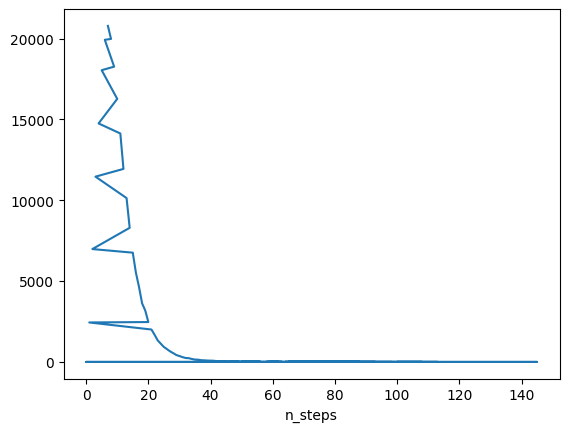

In [ ]:
recipes_df['n_steps'].value_counts().plot()

In [ ]:
# check for duplicate recipes
recipes_df.duplicated().sum()

np.int64(0)

In [ ]:
recipes_df[recipes_df['n_steps'] <= 20].shape

(219614, 12)

In [ ]:
recipes_df[recipes_df['n_ingredients'] <= 20].shape

(229998, 12)

In [ ]:
interactions_df[interactions_df['rating'] >= 4].shape

(1003724, 5)

In [ ]:
recipes_df[(recipes_df['n_ingredients'] <= 20) & (recipes_df['n_steps'] <= 20)].shape

(218591, 12)

In [ ]:
# let's check for for distinct n_steps 
sample_n_steps = [5 , 8 , 10 , 12 , 15 , 18 , 20 , 25] # random
for n in sample_n_steps:
    steps_subset = recipes_df[recipes_df['n_steps'] <= n]
    print(f"number of step with {n} covering: {(len(steps_subset) / len(recipes_df))*100}")

number of step with 5 covering: 23.17678091151241
number of step with 8 covering: 49.3781218026481
number of step with 10 covering: 64.28808869049418
number of step with 12 covering: 75.54319905714544
number of step with 15 covering: 86.41926807893385
number of step with 18 covering: 92.3695264573449
number of step with 20 covering: 94.80955115115461
number of step with 25 covering: 97.86433082797653


In [ ]:
# let's check for for distinct n_ingredients
sample_n_ingredients = [5 , 8 , 10 , 12 , 15 , 18 , 20 , 25] # random
for n in sample_n_ingredients:
    ingredients_subset = recipes_df[recipes_df['n_ingredients'] <= n]
    print(f"number of step with {n} covering: {(len(ingredients_subset) / len(recipes_df))*100}")

number of step with 5 covering: 17.190258896463
number of step with 8 covering: 48.26085642621861
number of step with 10 covering: 68.56374413414092
number of step with 12 covering: 83.35369565311241
number of step with 15 covering: 94.55138859508627
number of step with 18 covering: 98.37245345087356
number of step with 20 covering: 99.29242737559198
number of step with 25 covering: 99.89854815940458


In [ ]:
recipes_df.dropna(inplace = True)
interactions_df.dropna(inplace = True)

In [ ]:
interactions_df.head(4)

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...


In [ ]:
# Grouping by recipe_id and applying different aggregation rules
aggregated_interactions = interactions_df.groupby('recipe_id').agg({
    'rating': 'mean',
    'review': lambda x: x.dropna().astype(str).tolist(),
    'user_id' : 'count' # how many users reviewed it
}).reset_index()

In [ ]:
aggregated_interactions.head()

,recipe_id,rating,review,num of ratings
0,38,4.250000,"[Yummy, yummy, yummy! I am a big fan of fruit ...",4
1,39,3.000000,[I have an Indian friend who made this dish fo...,1
2,40,4.333333,[My favourite lemonade recipe is essentially t...,9
3,41,4.500000,[I thought this was very GOOD! ANYONE who is a...,2
4,43,1.000000,[did not work.],1


In [ ]:
aggregated_interactions.rename(columns = {
    "user_id" : 'num of ratings'
} , inplace = True)

In [ ]:
# combining both interactions_df and recipe dataset
recipes_df = recipes_df.merge(
    aggregated_interactions ,
    left_on = 'id',
    right_on = 'recipe_id',
    how = 'left'
)

In [ ]:
recipes_df.drop(columns = ['id'] , inplace = True)

In [ ]:
recipes_df.head(4)

,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings
0,arriba baked winter squash mexican style,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,137739.0,5.0,[ I used an acorn squash and recipe#137681 Swe...,3.0
1,a bit different breakfast pizza,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,31490.0,3.5,"[Have not tried this, but it sounds delicious....",4.0
2,all in the kitchen chili,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,112140.0,4.0,[I added black beans and corn to this and LOVE...,1.0
3,alouette potatoes,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11,59389.0,4.5,"[This is an excellent, easy-fix side-dish w/to...",2.0


In [ ]:
recipes_df[recipes_df['num of ratings'] > 10].shape

(18356, 15)

In [ ]:
import ast 
ast.literal_eval(recipes_df['nutrition'][0])

[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]

In [ ]:
recipes_df.shape

(231637, 12)

* we have total 231637 samples. For the first trial we will limit our self to 20 ingredients and 20 steps.
* So we want around ~15k samples
  - we will filter our dataset based on n_steps <= 20 and n_ingredients <= 20
  - Then we will take randomly 15k samples from the subset.

In [56]:
recipes_df.columns

Index(['name', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition',
       'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients',
       'recipe_id', 'rating', 'review'],
      dtype='str')

In [57]:
# sort based on ratings
recipes_df.sort_values(by = 'rating' , ascending = False , inplace = True)

In [58]:
recipes_df.head()

,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review
226654,zydeco ya ya deviled eggs,40,37779,2008-06-07,"['60-minutes-or-less', 'time-to-make', 'course...","[59.2, 6.0, 2.0, 3.0, 6.0, 5.0, 0.0]",7,"['in a bowl , combine the mashed yolks and may...","deviled eggs, cajun-style","['hard-cooked eggs', 'mayonnaise', 'dijon must...",8,308080.0,5.0,"[I loved these eggs. How different, how good, ..."
0,arriba baked winter squash mexican style,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,137739.0,5.0,[ I used an acorn squash and recipe#137681 Swe...
226653,zydeco spice mix,5,1500678,2013-01-09,"['15-minutes-or-less', 'time-to-make', 'course...","[14.8, 0.0, 2.0, 58.0, 1.0, 0.0, 1.0]",1,['mix all ingredients together thoroughly'],this spice mix will make your taste buds dance!,"['paprika', 'salt', 'garlic powder', 'onion po...",13,493372.0,5.0,[Made for New Kids on the Block tag game and f...
226652,zydeco soup,60,227978,2012-08-29,"['ham', '60-minutes-or-less', 'time-to-make', ...","[415.2, 26.0, 34.0, 26.0, 44.0, 21.0, 15.0]",7,"['heat oil in a 4-quart dutch oven', 'add cele...",this is a delicious soup that i originally fou...,"['celery', 'onion', 'green sweet pepper', 'gar...",22,486161.0,5.0,[Now the only substitution I made was African ...
226634,zuurkool met spek sauerkraut and pork hocks,195,64642,2007-07-01,"['time-to-make', 'course', 'main-ingredient', ...","[32.4, 0.0, 12.0, 46.0, 3.0, 0.0, 2.0]",3,['place pork hocks in a stockpot and add water...,"hollanders like plain, substantial food and lo...","['pork hocks', 'sauerkraut', 'salt and pepper']",3,238017.0,5.0,[I prepared this in a crockpot - cooked on low...


In [43]:
recipes_df[(recipes_df['n_ingredients'] <= 15) 
           & (recipes_df['n_steps'] <= 15) & (recipes_df['num of ratings'] > 10)].shape

(15709, 15)

In [42]:
recipes_df.dropna(inplace = True)

In [56]:
recipes_df_15k_samples = recipes_df[(recipes_df['n_ingredients'] <= 15) 
           & (recipes_df['n_steps'] <= 15) & (recipes_df['num of ratings'] > 10)].reset_index(drop=True)

In [51]:
recipes_df_15k_samples.rating.value_counts()

rating
5.000000    635
4.500000    407
4.666667    306
4.000000    302
4.750000    246
           ... 
4.177083      1
4.765152      1
4.378947      1
4.525253      1
4.019608      1
Name: count, Length: 2063, dtype: int64

In [58]:
# save the csv file
recipes_df_15k_samples.to_csv("data/all csv files/recipes_15k_samples.csv" , index = False)

In [5]:
# load the saved file
import pandas as pd
recipes_df_15k_samples = pd.read_csv("data/all csv files/recipes_15k_samples.csv")

In [6]:
recipes_df_15k_samples.head(2)

,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings
0,chicken lickin good pork chops,500,14664,2003-06-06,"['weeknight', 'time-to-make', 'course', 'main-...","[105.7, 8.0, 0.0, 26.0, 5.0, 4.0, 3.0]",5,"['dredge pork chops in mixture of flour , salt...",here's and old standby i enjoy from time to ti...,"['lean pork chops', 'flour', 'salt', 'dry must...",7,63986.0,4.368421,"[""I made this for dinner tonight and the chops...",19.0
1,chile rellenos,45,52268,2002-10-14,"['60-minutes-or-less', 'time-to-make', 'course...","[94.0, 10.0, 0.0, 11.0, 11.0, 21.0, 0.0]",9,"['drain green chiles', 'sprinkle cornstarch on...",a favorite from a local restaurant no longer i...,"['egg roll wrap', 'whole green chilies', 'chee...",5,43026.0,4.045455,"['Grandma Pam,\r\n Oh my goodness,these were ...",22.0


In [7]:
recipes_df_15k_samples['recipe_id'][0]

np.float64(63986.0)

In [8]:
recipes_df_15k_samples['recipe_id'].duplicated().sum()

np.int64(0)

In [9]:
recipes_df_15k_samples['review'][1]

'[\'Grandma Pam,\\r\\n  Oh my goodness,these were so easy to do,and they were so very good. We dipped them in salsa,and they were a hit with my husband.\\r\\nThank you so much!!!\\r\\nDarlene Summers\', \'WOW!  When you need a Mexican fix, this is the recipe to try.  These are so easy to make and really hit the spot!  I love the idea of being able to prepare them ahead of time.  Thank you for sharing this.  :-)\\r\\n\', "OMG!  If I could give this recipe more than 5 stars I would!  I loved the ease of prep, and the flavor was awesome!  I wasn\'t sure which size can to use, and realized that 1 4 oz was not nearly enough...it only had 3 chiles in it. hehe  So I would recommend at least 3 of those.  I made up a green gravy to serve with these as well that I will be posting.  Deeeeelicious!!!", "I have been searching for this recipe.  My husbands aunt made these once and we all loved them. I loved the simplicity of the egg roll wrapper!\\r\\n\\r\\nThanks for posting.  I probably won\'t mak

In [10]:
# clean up the review column values
import re 
import html
import ast 

def clean_reviews(review_input):
    # Check if the input is a string that looks like a list
    if isinstance(review_input, str) and review_input.startswith('['):
        try:
            review_list = ast.literal_eval(review_input)
        except (ValueError, SyntaxError):
            return []
    elif isinstance(review_input, list):
        review_list = review_input
    else:
        return []
    
    cleaned = []
    for review in review_list:
        # 1. Decode HTML entities
        review = html.unescape(review)
        
        # 2. Fix encoding artifacts
        review = review.encode('ascii', 'ignore').decode('ascii')
        
        # 3. & 4. Remove system characters and extra whitespace
        review = re.sub(r'\s+', ' ', review).strip()
        
        # 5. Filter short reviews
        if len(review) > 5:
            cleaned.append(review)
    
    return cleaned

In [11]:
clean_reviews(recipes_df_15k_samples['review'][3])

["I really enjoyed these burgers. The taste was great, I think it was the dry mustard. When I went to make them I didn't have any onions, but they still tasted good. The big shocker was picky eater son, ate the whole thing! That speaks for itself! Thanks for the terrific recipe.",
 "One word YUM!!! I'm not a huge fan of venison but I now know what to do with my freezer full. Not gamey at all! Thank you-can't wait to make a big batch to freeze.",
 "What a great way to use up some ground venison. I was surprised that it didn't taste like venison when cooked. I used my cast iron skillet to make them but DH and DS want them done on the grill next time. They were quick and easy to make. Thanks!",
 'Very good burgers! I did cook them on the grill, though. I skipped the chopped onions to avoid complaints from my son, but used onion powder to add some flavor, and used real eggs instead of egg substitute. An employee of my husband gave us some ground venison, and I have little experience with i

In [12]:
recipes_df_15k_samples['review'] = recipes_df_15k_samples['review'].apply(clean_reviews)

In [13]:
recipes_df_15k_samples.head(1)

,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings
0,chicken lickin good pork chops,500,14664,2003-06-06,"['weeknight', 'time-to-make', 'course', 'main-...","[105.7, 8.0, 0.0, 26.0, 5.0, 4.0, 3.0]",5,"['dredge pork chops in mixture of flour , salt...",here's and old standby i enjoy from time to ti...,"['lean pork chops', 'flour', 'salt', 'dry must...",7,63986.0,4.368421,[I made this for dinner tonight and the chops ...,19.0


In [14]:
recipes_df_15k_samples.columns

Index(['name', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition',
       'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients',
       'recipe_id', 'rating', 'review', 'num of ratings'],
      dtype='str')

In [15]:
recipes_df_15k_samples.drop(columns = ['contributor_id', 'submitted'] , inplace = True)

In [82]:
import ast
from IPython.display import Markdown, display

def display_recipe_card(row):
    # --- Helper to convert strings back to lists ---
    def safe_eval(val):
        if isinstance(val, str) and val.startswith('['):
            try:
                return ast.literal_eval(val)
            except:
                return val
        return val

    # Convert columns
    ingredients = safe_eval(row['ingredients'])
    steps = safe_eval(row['steps'])
    nutrition = safe_eval(row['nutrition'])
    tags = safe_eval(row['tags'])
    reviews = safe_eval(row['review'])

    # --- Use recipe_id instead of id ---
    # We use .get() or a conditional to handle both naming conventions
    r_id = row['recipe_id'] if 'recipe_id' in row else row.get('id', 'N/A')
    
    # --- Nutrition Table ---
    nutri_labels = ["Calories", "Total Fat (PDV)", "Sugar (PDV)", "Sodium (PDV)", 
                    "Protein (PDV)", "Saturated Fat (PDV)", "Total Carbs (PDV)"]
    
    nutri_table = "| Nutrient | Value |\n| :--- | :--- |\n"
    if isinstance(nutrition, list):
        for label, val in zip(nutri_labels, nutrition):
            nutri_table += f"| {label} | {val} |\n"
    else:
        nutri_table += "| Error | Could not parse nutrition data |\n"

    # --- Formatting ---
    steps_fmt = "\n".join([f"{i+1}. {s.strip().capitalize()}" for i, s in enumerate(steps)]) if isinstance(steps, list) else str(steps)
    ingredients_fmt = ", ".join(ingredients) if isinstance(ingredients, list) else str(ingredients)
    
    # --- Reviews ---
    reviews_limited = reviews[:3] if isinstance(reviews, list) else []
    reviews_formatted = "\n".join([f"> * \"{str(r)[:200]}...\"" for r in reviews_limited])
    
    # --- Build the Card ---
    markdown_content = f"""
#  {str(row['name']).title()}
**ID:** {int(r_id) if r_id != 'N/A' else r_id} | **Time:** {row['minutes']} mins | **Rating:** ⭐ {row['rating']:.2f} ({int(row['num of ratings'])} reviews)

### Description
{row['description']}

---

### Ingredients
{ingredients_fmt}

### Preparation Steps
{steps_fmt}

---

### Nutritional Information (per serving)
{nutri_table}

### Top Reviews
{reviews_formatted if reviews_formatted else "*No reviews available.*"}

---
**Tags:** `{', '.join(tags[:5]) if isinstance(tags, list) else ''}...`
"""
    display(Markdown(markdown_content))

In [84]:
display_recipe_card(recipes_df_15k_samples.iloc[10])


#  One Bowl  Perfect Pound Cake
**ID:** 26835 | **Time:** 70 mins | **Rating:** ⭐ 3.42 (12 reviews)

### Description
this is the perfect pound cake recipe...plus so easy to prepare and only one bowl to wash! this is a firm cake, so if you are into cutting and shaping cakes, this works well. i have used it for christening and communion cakes, creating crosses, etc and used buttercream frosting. i have also made it in a 9 x 13 cake pan...just adjust time accordingly. the addition of the yogurt really makes a difference in the taste.

---

### Ingredients
all-purpose flour, sugar, salt, baking soda, lemon, rind of, vanilla, butter, yogurt, eggs

### Preparation Steps
1. Preheat oven to 325 degrees and grease and flour a tube or bundt pan
2. Combine all ingredients in a large bowl and blend at low speed
3. Beat 3 minutes at medium speed
4. Pour into prepared pan
5. Bake for 1 hour or until top springs back when touched lightly in center
6. Cool in pan for about 15 minutes then remove and cool completely on rack
7. Serve plain or glaze if you like

---

### Nutritional Information (per serving)
| Nutrient | Value |
| :--- | :--- |
| Calories | 456.6 |
| Total Fat (PDV) | 32.0 |
| Sugar (PDV) | 164.0 |
| Sodium (PDV) | 15.0 |
| Protein (PDV) | 11.0 |
| Saturated Fat (PDV) | 63.0 |
| Total Carbs (PDV) | 20.0 |


### Top Reviews
> * "Delicious pound cake! I made this with the intention of using it as a base for other desserts calling for sliced pound cake, but this can stand on its own witha bit of powdered sugar dusted on top. I ..."
> * "This is the 'perfect' Pound Cake! I love the flavor with the vanilla yogurt and am looking forward to try it with another yogurt flavor! It's a keeper!..."
> * "This is really good - dense, firm and flavourful! I used "forest berries" yogurt that I needed to use up, and can't wait to serve this to people and play the "guess that flavour" game. ;-) Used only 1..."

---
**Tags:** `weeknight, time-to-make, course, main-ingredient, preparation...`


In [16]:
import ast

def recipe_to_markdown_string(row):
    # Helper to handle stringified lists from CSVs
    def safe_eval(val):
        if isinstance(val, str) and val.startswith('['):
            try:
                return ast.literal_eval(val)
            except:
                return val
        return val

    # Extract and clean data
    name = str(row['name']).title()
    r_id = int(row['recipe_id'])
    minutes = row['minutes']
    rating = round(row['rating'], 2)
    n_ratings = int(row['num of ratings'])
    description = row['description']
    
    ingredients = safe_eval(row['ingredients'])
    steps = safe_eval(row['steps'])
    nutrition = safe_eval(row['nutrition'])
    reviews = safe_eval(row['review'])

    # Format Nutrition
    nutri_labels = ["Calories", "Total Fat", "Sugar", "Sodium", "Protein", "Saturated Fat"]
    nutri_str = ", ".join([f"{l}: {v}" for l, v in zip(nutri_labels, nutrition)]) if isinstance(nutrition, list) else str(nutrition)

    # Format Lists
    ingredients_str = ", ".join(ingredients) if isinstance(ingredients, list) else str(ingredients)
    steps_str = "\n".join([f"{i+1}. {s.strip().capitalize()}" for i, s in enumerate(steps)]) if isinstance(steps, list) else str(steps)
    
    # Format Reviews (Top 5 for context)
    reviews_str = "\n".join([f"- {r}" for r in reviews[:5]]) if isinstance(reviews, list) else "No reviews."

    # Construct the final Markdown String
    markdown_text = f"""# {name}
**Recipe ID:** {r_id}
**Cook Time:** {minutes} minutes
**Rating:** {rating}/5 stars ({n_ratings} reviews)

## Description
{description}

## Ingredients
{ingredients_str}

## Instructions
{steps_str}

## Nutrition (PDV)
{nutri_str}

## Reviews
{reviews_str}
"""
    return markdown_text

In [17]:
print(recipe_to_markdown_string(recipes_df_15k_samples.iloc[10]))

# One Bowl  Perfect Pound Cake
**Recipe ID:** 26835
**Cook Time:** 70 minutes
**Rating:** 3.42/5 stars (12 reviews)

## Description
this is the perfect pound cake recipe...plus so easy to prepare and only one bowl to wash! this is a firm cake, so if you are into cutting and shaping cakes, this works well. i have used it for christening and communion cakes, creating crosses, etc and used buttercream frosting. i have also made it in a 9 x 13 cake pan...just adjust time accordingly. the addition of the yogurt really makes a difference in the taste.

## Ingredients
all-purpose flour, sugar, salt, baking soda, lemon, rind of, vanilla, butter, yogurt, eggs

## Instructions
1. Preheat oven to 325 degrees and grease and flour a tube or bundt pan
2. Combine all ingredients in a large bowl and blend at low speed
3. Beat 3 minutes at medium speed
4. Pour into prepared pan
5. Bake for 1 hour or until top springs back when touched lightly in center
6. Cool in pan for about 15 minutes then remove an

In [18]:
recipes_df_15k_samples['markdown_recipe'] = recipes_df_15k_samples.apply(recipe_to_markdown_string, axis=1)

In [19]:
# total 12 samples is failed while creating image recipe card
failed_recipe_ids_for_image = [3345 , 4802 , 5283 , 6951 , 6294 , 8565 , 11168 , 11310 , 13109 , 14774 , 15407 , 15407]
len(failed_recipe_ids_for_image)

12

In [20]:
recipes_df_15k_samples = recipes_df_15k_samples[~recipes_df_15k_samples['recipe_id'].isin(failed_recipe_ids_for_image)]

In [21]:
recipes_df_15k_samples.shape

(15709, 14)

* add the image recipe card to the dataframe

In [22]:
# convert recipe_id float to int
recipes_df_15k_samples['recipe_id'] = recipes_df_15k_samples['recipe_id'].astype(int)

In [23]:
recipes_df_15k_samples.head(2)

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings,markdown_recipe
0,chicken lickin good pork chops,500,"['weeknight', 'time-to-make', 'course', 'main-...","[105.7, 8.0, 0.0, 26.0, 5.0, 4.0, 3.0]",5,"['dredge pork chops in mixture of flour , salt...",here's and old standby i enjoy from time to ti...,"['lean pork chops', 'flour', 'salt', 'dry must...",7,63986,4.368421,[I made this for dinner tonight and the chops ...,19.0,# Chicken Lickin Good Pork Chops\n**Recipe I...
1,chile rellenos,45,"['60-minutes-or-less', 'time-to-make', 'course...","[94.0, 10.0, 0.0, 11.0, 11.0, 21.0, 0.0]",9,"['drain green chiles', 'sprinkle cornstarch on...",a favorite from a local restaurant no longer i...,"['egg roll wrap', 'whole green chilies', 'chee...",5,43026,4.045455,"[Grandma Pam, Oh my goodness,these were so eas...",22.0,# Chile Rellenos\n**Recipe ID:** 43026\n**Cook...


In [24]:
# add recipe card image file path to the recipe

image_dir = "data/output/images"

recipes_df_15k_samples['image_path'] = recipes_df_15k_samples['recipe_id'].apply(
    lambda x: f"{image_dir}/recipe_id_{x}.png"
    if os.path.exists(os.path.join(image_dir, f"recipe_id_{x}.png")) 
    else "no image"
)

In [25]:
recipes_df_15k_samples = recipes_df_15k_samples[recipes_df_15k_samples['image_path'] != "no image"]

In [26]:
recipes_df_15k_samples.shape

(15698, 15)

In [27]:
recipes_df_15k_samples.columns

Index(['name', 'minutes', 'tags', 'nutrition', 'n_steps', 'steps',
       'description', 'ingredients', 'n_ingredients', 'recipe_id', 'rating',
       'review', 'num of ratings', 'markdown_recipe', 'image_path'],
      dtype='str')

In [40]:
import random
print(recipes_df_15k_samples['markdown_recipe'][random.randint(0 , len(recipes_df_15k_samples) - 1)])

# Gnocchi Bake With Pancetta And Red Onion
**Recipe ID:** 368572
**Cook Time:** 40 minutes
**Rating:** 4.83/5 stars (12 reviews)

## Description
this is easy to make and yet tastes fabulous! as always, good quality mascarpone will yield a much richer flavour.

## Ingredients
olive oil, pancetta, red onion, garlic cloves, chopped tomato, sun-dried tomato paste, mascarpone cheese, gnocchi, fresh basil leaves, mozzarella cheese, white breadcrumb

## Instructions
1. Preheat the oven to 350f / 180c
2. Heat the oil in a skillet and add the pancetta
3. Cook over a medium heat , stirring frequently , for 1 minute
4. Add the red onion and garlic and cook , stirring , for a further 5 minutes , or until the pancetta is cooked and the onion softened
5. Stir in the chopped tomatoes , sun-dried tomato paste , and mascarpone cheese
6. Simmer over a low heat for 5 minutes
7. Meanwhile , cook the gnocchi for 1-2 minutes , until they rise to the surface
8. Do not overcook
9. Drain the gnocchi thoroughly

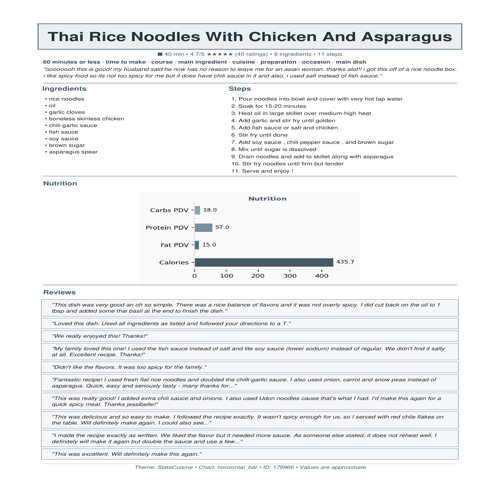

In [44]:
from transformers.image_utils import load_image
load_image(recipes_df_15k_samples['image_path'][random.randint(0 , len(recipes_df_15k_samples) - 1)]).resize(size = (500 , 500))

In [46]:
# save the final csv file
recipes_df_15k_samples.to_csv("data/all csv files/recipes_15k_samples.csv" , index = False)

In [47]:
recipes_df_15k_samples = pd.read_csv("data/all csv files/recipes_15k_samples.csv")
recipes_df_15k_samples.head()

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings,markdown_recipe,image_path
0,chicken lickin good pork chops,500,"['weeknight', 'time-to-make', 'course', 'main-...","[105.7, 8.0, 0.0, 26.0, 5.0, 4.0, 3.0]",5,"['dredge pork chops in mixture of flour , salt...",here's and old standby i enjoy from time to ti...,"['lean pork chops', 'flour', 'salt', 'dry must...",7,63986,4.368421,"[""I made this for dinner tonight and the chops...",19.0,# Chicken Lickin Good Pork Chops\n**Recipe I...,data/output/images/recipe_id_63986.png
1,chile rellenos,45,"['60-minutes-or-less', 'time-to-make', 'course...","[94.0, 10.0, 0.0, 11.0, 11.0, 21.0, 0.0]",9,"['drain green chiles', 'sprinkle cornstarch on...",a favorite from a local restaurant no longer i...,"['egg roll wrap', 'whole green chilies', 'chee...",5,43026,4.045455,"['Grandma Pam, Oh my goodness,these were so ea...",22.0,# Chile Rellenos\n**Recipe ID:** 43026\n**Cook...,data/output/images/recipe_id_43026.png
2,chinese candy,15,"['15-minutes-or-less', 'time-to-make', 'course...","[232.7, 21.0, 77.0, 4.0, 6.0, 38.0, 8.0]",4,['melt butterscotch chips in heavy saucepan ov...,"a little different, and oh so good. i include ...","['butterscotch chips', 'chinese noodles', 'sal...",3,23933,4.833333,"[""A bit different, maybe...but these are delic...",12.0,# Chinese Candy\n**Recipe ID:** 23933\n**Cook...,data/output/images/recipe_id_23933.png
3,grilled venison burgers,26,"['30-minutes-or-less', 'time-to-make', 'course...","[190.9, 10.0, 10.0, 10.0, 45.0, 15.0, 2.0]",13,"['in bowl , mix dry ingredients', 'add venison...",delicious venison burgers with that,"['ground venison', 'egg substitute', 'non-fat ...",10,54100,4.428571,"[""I really enjoyed these burgers. The taste wa...",14.0,# Grilled Venison Burgers\n**Recipe ID:** 541...,data/output/images/recipe_id_54100.png
4,healthy for them yogurt popsicles,10,"['15-minutes-or-less', 'time-to-make', 'course...","[164.6, 3.0, 5.0, 1.0, 4.0, 6.0, 11.0]",3,"['mix all the ingredients using a blender', 'p...",my children and their friends ask for my homem...,"['milk', 'frozen juice concentrate', 'plain yo...",3,67664,4.833333,['My lips are still smacking away. These are F...,12.0,# Healthy For Them Yogurt Popsicles\n**Recipe...,data/output/images/recipe_id_67664.png
